## **Gradient Descent visualization**

Text from *Machine Learning Specialization*

In machine learning *gradient descent* is described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  
The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.datasets import load_diabetes

In [2]:
x1 = np.linspace(-5,5,30)
y = x1*2 + 1.5

#### Defining the grid params, aiming to have convex shape

In [3]:
b_range = np.linspace(-20, 20, 30)
w_range = np.linspace(-20, 20, 30)

In order to calculate Cost function, I need to care about multiplication of dimensions:

$$ y^T \in \mathbb{R}^{m \times m \times n} $$

Key Rules for Broadcasting ( by NumPy documentation):

**1**) Dimension Alignment: Shapes are compared from the trailing (rightmost) dimensions, moving forward.

**2**) Compatibility: Dimensions are compatible if they are equal, or if one of them is 1.

**3**) Expansion: If a dimension is 1, it is stretched (broadcast) to match the corresponding dimension of the other array.

In [4]:
class Round1():
    def __init__(self,x,y,w,b):
        self.x=x
        self.y=y
        self.w=w
        self.b=b
        self.m = len(w)
        self.n = len(x)
    def meshgrid(self):
        B,W = np.meshgrid(self.b,self.w)
        return B,W
    def pre_calculation(self):
        """ Preparing the data for arithemtic computation"""
        B,W = self.meshgrid()

        # Dynamic reshape here:
        B_3d = B.reshape(self.m,self.m,1)
        W_3d = W.reshape(self.m,self.m,1)
        X_3d = self.x.reshape(1,1,self.n)
        Y_3d = self.y.reshape(1,1,self.n)
        return B_3d,W_3d,X_3d,Y_3d
    
    def get_cost(self):
        b,w,x,y = self.pre_calculation()
        pred = w*x + b
        residuals = (y-pred)**2
        cost = 1/(2*self.n)*np.sum(residuals**2,axis=2)
        return cost
    def plot3d(self):
        B,W = self.meshgrid()
        cost_values = self.get_cost()
        fig= plt.figure(figsize=(12,8))
        ax = fig.add_subplot(111,projection='3d')
        ax.plot_surface(B,W,cost_values)
        ax.view_init(25,25)
        plt.show()

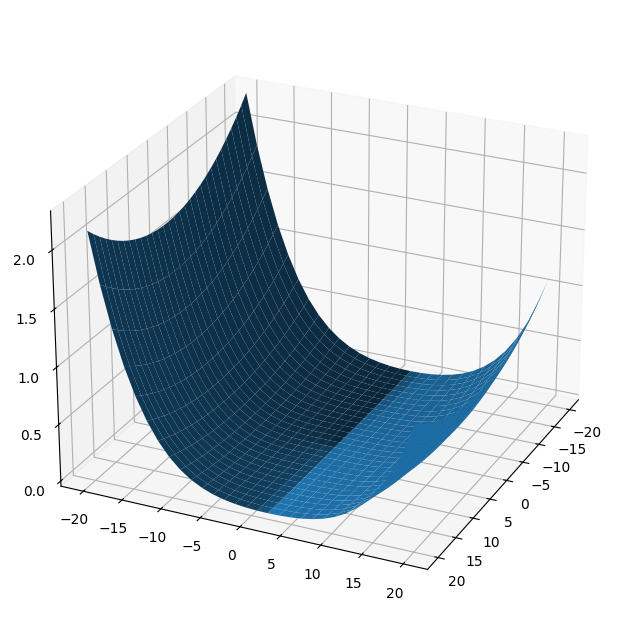

In [5]:
r = Round1(x1,y,w_range,b_range)
r.meshgrid()
r.pre_calculation()
r.get_cost()
r.plot3d()

### Implementing Gradient Descent


Conventions:
- The naming of python variables containing partial derivatives follows this pattern,$\frac{\partial J(w,b)}{\partial b}$  will be `dj_db`.
- w.r.t is With Respect To, as in partial derivative of $J(wb)$ With Respect To $b$.

#### I will use different training set examples for the convenience of better visual representation:

In [6]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [7]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])

#### Computing the cost:

In [315]:
class Cost():
    def __init__(self,x,y,w,b,):
        self.x=x
        self.y=y
        self.w=w
        self.b=b
    def get_cost_loop(self):
        m = self.x.shape[0]
        n = self.x.shape[1]
        #print(self.x.shape)
        #print(self.w.shape)
        total_cost = 0
        for i in range(m): # MATRIX MULTIPLICATION REMINDER! -> if X is matrix in shape of (3,4), by taking all the rows of 1st column * row vector W = correct way also 
            pred = np.dot(self.w,self.x[i]) + self.b
            error = pred - self.y[i]
            error_sq = error**2
            total_cost +=error_sq
            cost = 1/(2*m)*total_cost.sum()

        return cost

    def get_cost_no_loop(self):
        m = self.x.shape[0]
        pred = np.dot(self.x,self.w)+self.b
        error = (self.y-pred)**2
        cost = 1/(2*m)*error.sum()
        return cost

In [129]:
c =Cost(X_train,y_train,w_init,b_init)
print(c.get_cost_loop())
print(c.get_cost_no_loop())

(3, 4)
(4,)
1.5578904880036537e-12
1.5578904045996674e-12


In [295]:
def compute_gradient(x,y,w,b):
  """
  Computes the gradient for linear regression 
  """
  # Gradient of b defined as convention: dj_db 
  # Gradient of w defined as convention: dj_dw 
  m,n = x.shape
  dj_dw = np.zeros((n,)) # n because for n number of features
  dj_db = 0 # zero because it's only for b only one bias

  for i in range(m):
    error = (np.dot(x[i],w)+b) - y[i]
    for j in range(n):
      dj_dw = dj_dw + np.sum(error) * x[i,j]
    dj_db =dj_db + np.sum(error)
  
  dj_db = dj_db/m
  dj_dw = dj_dw/m
  return dj_db,dj_dw
    

In [296]:
tmp_db,tmp_dw = compute_gradient(X_train,y_train,w_init,b_init)

In [127]:
print(tmp_db,tmp_dw)

-1.673925169143331e-06 [-0.00280397 -0.00280397 -0.00280397 -0.00280397]


### **Computed gradinet shows as above:**

#### **1) Gradient for _b_ is very small and likely it's very optmised**

#### **2) Gradients for weights _w_ are all similar (good sign - consistent), and the negative sign indicates that we need to INCREASE the w values to move toward the minimum**

- increasing because of the formula

tmp_dw = dw - alpha * (gradient)

We need to increase w (because gradient is negative) with small alpha to get closer to minimum!

In [352]:
def gradient_descent_final(x,y,w,b,compute_gradient,cost_obj,alpha,num_iters):
    # dj_dw =dj_dw + sum Error * Xi
    history_data = []
    i = 0
    while i < num_iters:
        dj_db,dj_dw = compute_gradient(x,y,w,b)
        w = w - alpha*(dj_dw)
        b = b - alpha*(dj_db)
        cost_obj = Cost(X_train,y_train,w,b)
        cost = cost_obj.get_cost_loop()
        #print(cost)
        i+=1
        history_data.append({
            'Num. iter.': i,
            'b_history': b,
            'w_history':w,
            'cost':cost
        })
    return w,b,history_data


In [353]:
initial_w = np.zeros_like(w_init)
initial_b = 0
num_iters= 1000
alpha = 5.0e-7

w_final,b_final,history = gradient_descent_final(X_train,y_train,initial_w,initial_b,compute_gradient,Cost,alpha,num_iters)


In [354]:
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

b,w found by gradient descent: -0.00,[0.1966389 0.1966389 0.1966389 0.1966389] 
prediction: 423.75, target value: 460
prediction: 287.29, target value: 232
prediction: 175.01, target value: 178


In [ ]:
# 3d plot cost ,b , w 
# surface plot na grafiku sa strelicama za gradijent

[{'Num. iter.': 1, 'b_history': np.float64(0.000145), 'w_history': array([0.248112, 0.248112, 0.248112, 0.248112]), 'cost': np.float64(4073.1614111188924)}, {'Num. iter.': 2, 'b_history': np.float64(0.00010366781550000003), 'w_history': array([0.18316254, 0.18316254, 0.18316254, 0.18316254]), 'cost': np.float64(959.0067701981673)}, {'Num. iter.': 3, 'b_history': np.float64(0.00011111269784362924), 'w_history': array([0.20016467, 0.20016467, 0.20016467, 0.20016467]), 'cost': np.float64(745.6060850410049)}, {'Num. iter.': 4, 'b_history': np.float64(0.00010578897440832995), 'w_history': array([0.19571394, 0.19571394, 0.19571394, 0.19571394]), 'cost': np.float64(730.9825687626189)}, {'Num. iter.': 5, 'b_history': np.float64(0.00010380775012474909), 'w_history': array([0.19687903, 0.19687903, 0.19687903, 0.19687903]), 'cost': np.float64(729.9804638379846)}, {'Num. iter.': 6, 'b_history': np.float64(0.00010095154403889379), 'w_history': array([0.19657404, 0.19657404, 0.19657404, 0.19657404])

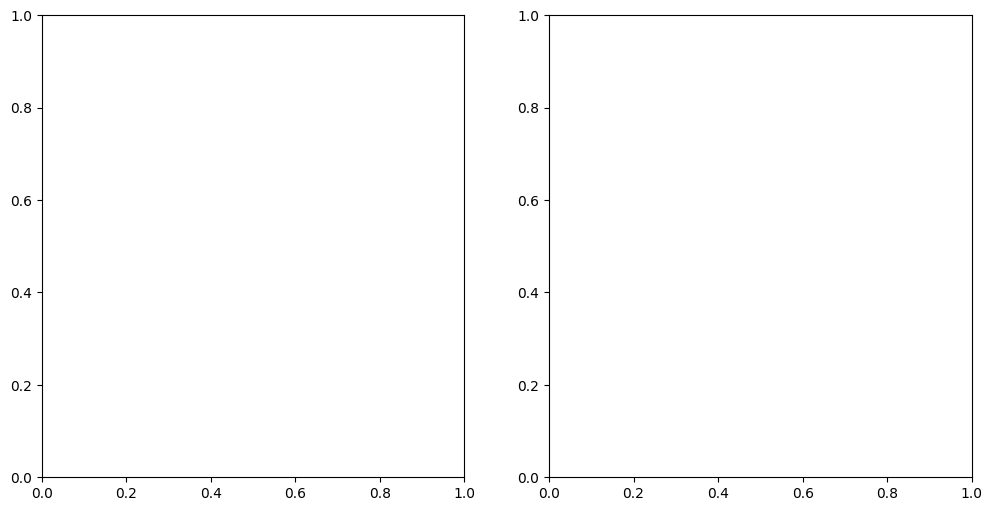

In [362]:
fig, ax = plt.subplots(1,2,figsize=(12,6))